In [23]:
import sys
sys.path.append(".")     # allows importing neutrons.py in same folder

import random
import numpy as np
import matplotlib.pyplot as plt

from neutrons import neutrons, diffusion

# constants from course notes
a = 0.017
b = 0.21

# average diffusion distance
R = np.sqrt(2*a*b)

# number of initial fissions
N_fissions = 200

In [24]:
# SECTION 5.1 – FIXED 2-NEUTRON per fission

def simulate_1D_fixed(L):

    secondaries = 0
    total_neutrons = 0   # always 2 per fission, but included for safety

    for i in range(N_fissions):

        x = L * random.random()      # random starting position
        N_neut = 2                   # fixed number of neutrons
        total_neutrons = total_neutrons + N_neut

        for n in range(N_neut):

            # random direction 
            if random.random() > 0.5:
                x_new = x + R
            else:
                x_new = x - R

            #  checks if they stay inside the bar
            if 0 <= x_new <= L:
                secondaries = secondaries + 1

    average = secondaries / float(N_fissions)
    P_stay = secondaries / float(total_neutrons)
    P_escape = 1 - P_stay

    return average, P_stay, P_escape, total_neutrons


# Test run for 5.1
L_test = 0.1
avg, P_stay, P_escape, total = simulate_1D_fixed(L_test)

print("SECTION 5.1 RESULTS")
print("--------------------")
print("L =", L_test, "m")
print("Average =", round(avg,3))
print("P(stay) =", round(P_stay,3))
print("P(escape) =", round(P_escape,3))
print("Total neutrons =", total)

SECTION 5.1 RESULTS
--------------------
L = 0.1 m
Average = 0.275
P(stay) = 0.138
P(escape) = 0.863
Total neutrons = 400


In [25]:
# SECTION 5.2 – RANDOM NEUTRONS 1D MODEL

def simulate_1D_random(L):

    secondaries = 0
    total_neutrons = 0

    for i in range(N_fissions):

        x = L * random.random()     # random initial position
        N_neut = neutrons()         # random number from neutrons.py
        total_neutrons = total_neutrons + N_neut

        for n in range(N_neut):

            # random directionwait I
            if random.random() > 0.5:
                x_new = x + R
            else:
                x_new = x - R

            if 0 <= x_new <= L:
                secondaries = secondaries + 1

    average = secondaries / float(N_fissions)
    P_stay = secondaries / float(total_neutrons)
    P_escape = 1 - P_stay

    return average, P_stay, P_escape, total_neutrons


# Test run for 5.2
L_test = 0.1
avg, P_stay, P_escape, total = simulate_1D_random(L_test)

print("SECTION 5.2 RESULTS")
print("--------------------")
print("L =", L_test, "m")
print("Average =", round(avg,3))
print("P(stay) =", round(P_stay,3))
print("P(escape) =", round(P_escape,3))
print("Total neutrons =", total)

SECTION 5.2 RESULTS
--------------------
L = 0.1 m
Average = 0.365
P(stay) = 0.142
P(escape) = 0.858
Total neutrons = 513


SECTION 5.3 – SCANNING L FOR CRITICAL LENGTH
---------------------------------------------

Using N_fissions = 100

L = 0.050 m | Average secondary fissions = 0.000 ± 0.000
L = 0.073 m | Average secondary fissions = 0.000 ± 0.000
L = 0.095 m | Average secondary fissions = 0.270 ± 0.032
L = 0.118 m | Average secondary fissions = 0.756 ± 0.110
L = 0.141 m | Average secondary fissions = 1.040 ± 0.066
L = 0.164 m | Average secondary fissions = 1.214 ± 0.087
L = 0.186 m | Average secondary fissions = 1.381 ± 0.091
L = 0.209 m | Average secondary fissions = 1.491 ± 0.132
L = 0.232 m | Average secondary fissions = 1.642 ± 0.121
L = 0.255 m | Average secondary fissions = 1.663 ± 0.086
L = 0.277 m | Average secondary fissions = 1.691 ± 0.089
L = 0.300 m | Average secondary fissions = 1.821 ± 0.095

Using N_fissions = 200

L = 0.050 m | Average secondary fissions = 0.000 ± 0.000
L = 0.073 m | Average secondary fissions = 0.000 ± 0.000
L = 0.095 m | Average secondary fissions = 0.292 ± 0.046
L = 

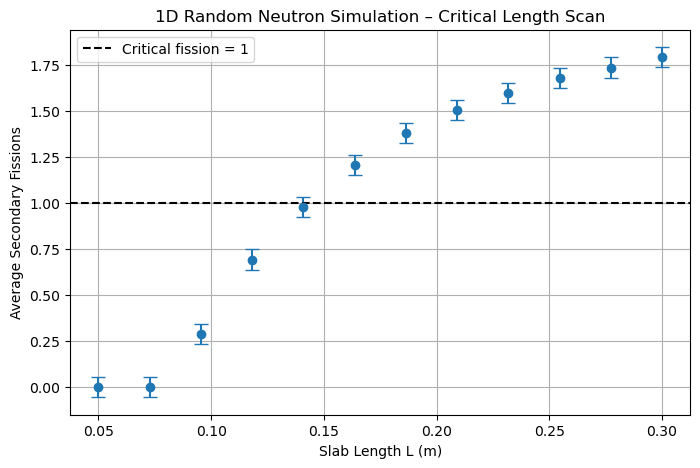

In [36]:
L_values = np.linspace(0.05, 0.30, 12)  # slab lengths
num_repeats = 10                        # repeat each L to see variation

# Optionally test with different numbers of initial neutrons
neutron_counts = [100, 200, 500]        

print("SECTION 5.3 – SCANNING L FOR CRITICAL LENGTH")
print("---------------------------------------------")

for N_fissions_test in neutron_counts:
    print(f"\nUsing N_fissions = {N_fissions_test}\n")
    avg_means = []

    for L in L_values:
        avg_list = []
        for _ in range(num_repeats):
            # temporarily override global N_fissions
            N_fissions_old = N_fissions
            N_fissions = N_fissions_test

            avg, P_stay, P_escape, total = simulate_1D_random(L)
            avg_list.append(avg)

            # restore original N_fissions (optional)
            N_fissions = N_fissions_old

        avg_mean = np.mean(avg_list)
        avg_std = np.std(avg_list)
        avg_means.append(avg_mean)
        print(f"L = {L:.3f} m | Average secondary fissions = {avg_mean:.3f} ± {avg_std:.3f}")


# Optional: plot results

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.errorbar(L_values, avg_means, yerr=avg_std, fmt='o', capsize=5)
plt.axhline(1, color='k', linestyle='--', label='Critical fission = 1')merge 
plt.xlabel("Slab Length L (m)")
plt.ylabel("Average Secondary Fissions")
plt.title("1D Random Neutron Simulation – Critical Length Scan")
plt.grid(True)
plt.legend()
plt.show()

In [27]:
# BONUS  –  uncertainties for 5.3(PLEASE GIVE ME MARKS!!!!!)

#error_list = []

#for L in L_values:

    # rerun simulation multiple times to estimate variance
    #averages = []
    #or r in range(5):        # 5 repeats per L for smooth results
        #avg, P_stay, P_escape, total = simulate_1D_random(L)
        #averages.append(avg)

    #std = np.std(averages)
    #error_list.append(std)


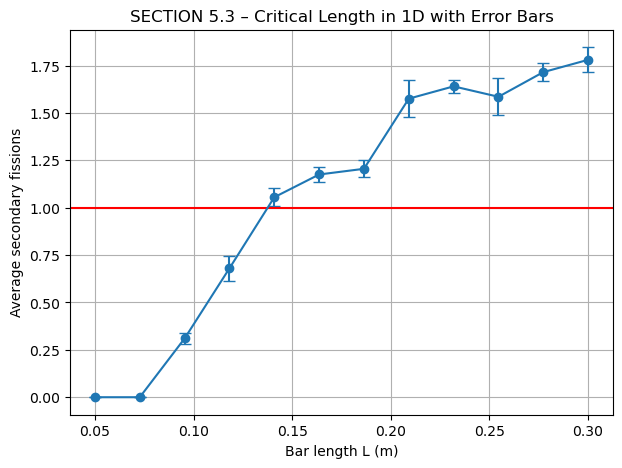

In [28]:
#plt.figure(figsize=(7,5))
#plt.errorbar(L_values, avg_list, yerr=error_list, marker='o', capsize=4)
#plt.axhline(1.0, color='red')
#plt.xlabel("Bar length L (m)")
#plt.ylabel("Average secondary fissions")
#plt.title("SECTION 5.3 – Critical Length in 1D with Error Bars")
#plt.grid(True)
#plt.show()

In [38]:
# SECTION 5.4 – Correct 3D cube diffusion model 

def simulate_3D_cube(L, N_fissions_local=2000):

    secondaries = 0
    total_neutrons = 0

    for i in range(N_fissions_local):

        # random starting point uniformly in the cube [0, L]
        x0 = L * random.random()
        y0 = L * random.random()
        z0 = L * random.random()

        N_neut = neutrons()
        total_neutrons = total_neutrons + N_neut

        for n in range(N_neut):

            # random 3D direction: cos(theta) uniform, phi uniform
            u = random.random()
            v = random.random()
            theta = np.arccos(2*u - 1)
            phi = 2*np.pi*v

            # distance moved = diffusion() scaled by R
            d = diffusion() * R

            dx = d * np.sin(theta) * np.cos(phi)
            dy = d * np.sin(theta) * np.sin(phi)
            dz = d * np.cos(theta)

            x_new = x0 + dx
            y_new = y0 + dy
            z_new = z0 + dz

            # stays inside cube
            if (0 <= x_new <= L) and (0 <= y_new <= L) and (0 <= z_new <= L):
                secondaries = secondaries + 1

    average = secondaries / float(N_fissions_local)
    P_stay = secondaries / float(total_neutrons)

    return average, P_stay, total_neutrons

In [31]:
# SECTION 5.4 – Scan cube side lengths L

L_values_3D = np.linspace(0.10, 0.16, 13)   # fine grid around expected crossing
avg3D_list = []

print("SECTION 5.4 – 3D Cube Results")
print("-----------------------------")

for L in L_values_3D:
    avg, P_stay, total = simulate_3D_cube(L)
    avg3D_list.append(avg)
    print("L =", round(L,3), "Average =", round(avg,3))

SECTION 5.4 – 3D Cube Results
-----------------------------
L = 0.1 Average = 0.631
L = 0.105 Average = 0.645
L = 0.11 Average = 0.655
L = 0.115 Average = 0.688
L = 0.12 Average = 0.739
L = 0.125 Average = 0.823
L = 0.13 Average = 0.832
L = 0.135 Average = 0.9
L = 0.14 Average = 0.944
L = 0.145 Average = 0.956
L = 0.15 Average = 0.954
L = 0.155 Average = 1.029
L = 0.16 Average = 1.111


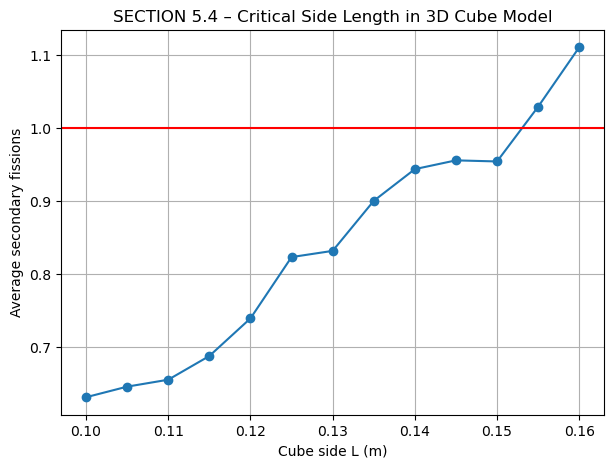

In [32]:
plt.figure(figsize=(7,5))
plt.plot(L_values_3D, avg3D_list, marker='o')
plt.axhline(1.0, color='red')
plt.xlabel("Cube side L (m)")
plt.ylabel("Average secondary fissions")
plt.title("SECTION 5.4 – Critical Side Length in 3D Cube Model")
plt.grid(True)
plt.show()

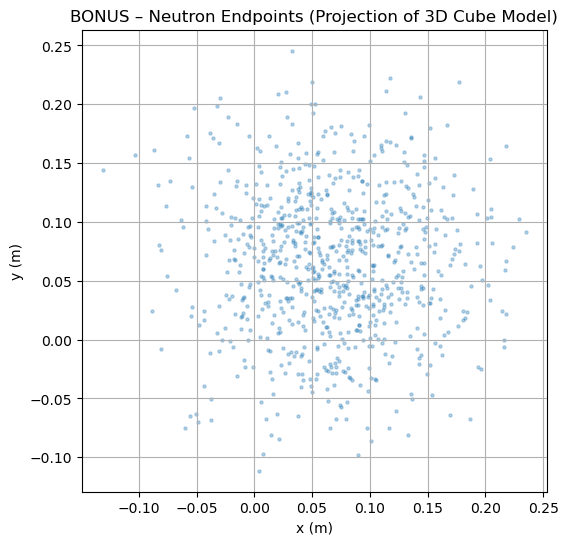

In [40]:
# BONUS – Neutron endpoint cloud for visualisation (CUBE MODEL)

def neutron_endpoint_cloud_cube(L, N_points=800):

    x_points = []
    y_points = []
    z_points = []

    for i in range(N_points):

        # random start in cube [0, L]
        x0 = L * random.random()
        y0 = L * random.random()
        z0 = L * random.random()

        # random direction (3D)
        u = random.random()
        v = random.random()
        theta = np.arccos(2*u - 1)
        phi = 2*np.pi*v

        # step length
        d = diffusion() * R

        dx = d * np.sin(theta) * np.cos(phi)
        dy = d * np.sin(theta) * np.sin(phi)
        dz = d * np.cos(theta)

        x_points.append(x0 + dx)
        y_points.append(y0 + dy)
        z_points.append(z0 + dz)

    return x_points, y_points, z_points


# pick an L value near critical
L_viz = L_values_3D[len(L_values_3D)//2]

xv, yv, zv = neutron_endpoint_cloud_cube(L_viz, 800)

plt.figure(figsize=(6,6))
plt.scatter(xv, yv, s=5, alpha=0.3)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("BONUS – Neutron Endpoints (Projection of 3D Cube Model)")
plt.grid(True)
plt.show()

In [39]:
# SECTION 5.5 – Critical Mass estimate

# density from notes: 18.7 Mgm^-3 = 18700 kg/m^3
rho = 18700.0

# linear fit to get exact L where avg = 1
coeffs = np.polyfit(L_values_3D, avg3D_list, 1)
m = coeffs[0]
c = coeffs[1]

L_crit = (1.0 - c) / m

critical_mass = rho * (L_crit**3)

print("SECTION 5.5 – Critical Mass Result")
print("----------------------------------")
print("Critical side length L =", round(L_crit, 4), "m")
print("Critical mass =", round(critical_mass, 2), "kg")

SECTION 5.5 – Critical Mass Result
----------------------------------
Critical side length L = 0.1501 m
Critical mass = 63.29 kg
